# Sentiment Analysis 

This notebook implements sentiment analysis, to assign a numeric value to the sentiment of comments. 

In [3]:
import numpy as np
import regex

from transformers import BertTokenizerFast, pipeline

from database.comments import Comments

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks

Can use the sentiment analysis pipeline from HuggingFace

In [4]:
cs = Comments(env='dev')
nlp = NLP_Tasks()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [5]:
df = cs.read_all()
df = df
print('df shape:', df.shape)

df shape: (30393, 14)


In [6]:
sentiment_model = pipeline(model="finiteautomata/bertweet-base-sentiment-analysis")

def split_period_or_length(comment, max_length=100):
    sentences = regex.split(r'(?<=[.!?]) +', comment)
    split_sentences = []
    for sentence in sentences:
        if len(sentence) > max_length:
            # Split long sentences into smaller chunks
            for i in range(0, len(sentence), max_length):
                split_sentences.append(sentence[i:i + max_length])
        else:
            split_sentences.append(sentence)
    return split_sentences

def sentiment_score(comment, stance):
    
    # Split the comment into sentences
    # sentences = regex.split(r'(?<=[.!?]) +', comment)
    sentences = split_period_or_length(comment, max_length=100)
    n = len(sentences)

    # Analyse sentiment for each sentence
    sentiment_results = sentiment_model(sentences)

    # Calculate score by adding 'POS' scores and subtracting 'NEG' scores
    score = 0
    for result in sentiment_results:
        if result['label'] == 'POS':
            score += result['score']
        elif result['label'] == 'NEG':
            score -= result['score']

    score = float(score / n)

    # Adjust score based on stance
    if stance == 'Objects' and score > 0:
        score = 0
    elif stance == 'Supports' and score < 0:
        score = 0

    return score

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use mps:0


### Practise sentiment scoring 

In [7]:
sentiment_model = pipeline(model="finiteautomata/bertweet-base-sentiment-analysis")

id = df['comment_id'][3]
comment = df['cleaned_comment_text'][3]
stance = df['stance'][3]
score = nlp.sentiment_score(comment, stance, sentiment_model)

cs.update_sentiment_score_by_comment_id(id, score)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use mps:0


Successfully updated sentiment_score for comment_id 23/2612/PNE_5: -0.4125039898432218


True

In [8]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,79910,Brent,23/2303_10,23/2303,"49 St Gabriels Road, London, NW2 4DT",Objects,2023-09-14,The proposed house is out of keeping with the ...,2025-04-08,51.474668,-0.105307,The proposed house is out of keeping with the ...,E09000022,-0.309787
1,79913,Brent,23/2303_13,23/2303,"45 St Gabriels Road, London, NW2 4DT",Objects,2023-09-12,If the council's planning department allows th...,2025-04-08,51.474668,-0.105307,If the council's planning department allows th...,E09000022,-0.508164
2,74170,Ealing,225185FUL_132,225185FUL,4 Marlborough Road Ealing LONDON W5 5NY W5 5NY,Objects,2023-01-22,The current house at no6 is a major feature of...,2025-04-07,51.505460,-0.301420,The current house at is a major feature of . I...,E09000009,-0.343599
3,89031,Barnet,23/2612/PNE_5,23/2612/PNE,14 Park Road High Barnet EN5 5SQ,Objects,2023-07-17,The property in question has 8 flats currently...,2025-04-10,51.653078,-0.197148,The property in question has 8 flats currently...,E09000003,-0.412504
4,89490,Ealing,212170FUL_56,212170FUL,29 Park Place Ealing W5 5NQ W5 5NQ,Objects,2021-09-29,I strongly object to this revised proposal. Co...,2025-04-10,51.508277,-0.303380,I strongly object to this revised proposal. Co...,E09000009,-0.572075


In [9]:
# sns colour palette for stance 
stance_palette = {
    'Supports': '#5B76BD',  # blue
    'Objects': '#B04F2C',   # orange
    'Neutral': '#82B02C'    # green
}

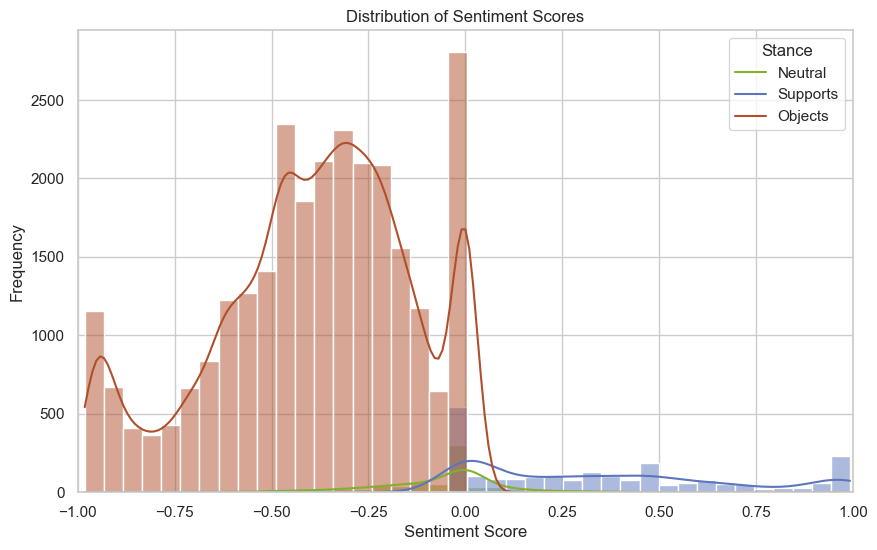

In [10]:
# Plot histogram of sentiment scores
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sentiment_score", bins=40, kde=True, hue="stance", legend=True, palette=stance_palette)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.xlim(-1, 1)
plt.legend(title='Stance', loc='upper right', labels=['Neutral', 'Supports', 'Objects'])
# plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
# plt.legend()
plt.show()

Regex matching keywords in the comments 

In [16]:
def keyword_match(df, column, keyword):
    pattern = rf'\b{regex.escape(keyword)}s?\b'
    matched_comments = df[df[column].str.contains(pattern, flags=regex.IGNORECASE, regex=True, na=False)]
    n = len(matched_comments)
    print(f"Number of comments mentioning '{keyword}': {n}")
    return matched_comments

In [ ]:
drug_comments = keyword_match(df, 'cleaned_comment_text', 'drug')

# average sentiment score for drug comments
avg_drug_sentiment = drug_comments['sentiment_score'].mean()
print(f"Average sentiment score for comments mentioning 'drug': {avg_drug_sentiment}")

Number of comments mentioning 'drug': 225
